### Section1: Load dataset and basic overview

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the cleaned traffic accidents dataset
df = pd.read_csv(r"..\data\processed\traffic_accidents_cleaned.csv")

# Basic overview
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209275 entries, 0 to 209274
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   record_id                    209275 non-null  int64 
 1   traffic_control_device       209275 non-null  object
 2   weather_condition            209275 non-null  object
 3   lighting_condition           209275 non-null  object
 4   first_crash_type             209275 non-null  object
 5   trafficway_type              209275 non-null  object
 6   alignment                    209275 non-null  object
 7   roadway_surface_cond         209275 non-null  object
 8   road_defect                  209275 non-null  object
 9   crash_type                   209275 non-null  object
 10  intersection_related_i       209275 non-null  object
 11  prim_contributory_cause      209275 non-null  object
 12  num_units                    209275 non-null  int64 
 13  num_units_was_

The dataset contains 209,275 records and 17 columns. Each row represents one traffic accident record. The dataset has no missing values and has already been cleaned. Columns include numeric measurements such as `num_units` and categorical features like `crash_type`, `traffic_control_device`, `weather_condition`, and `most_severe_injury`.

### Section 2: Univariate Analysis

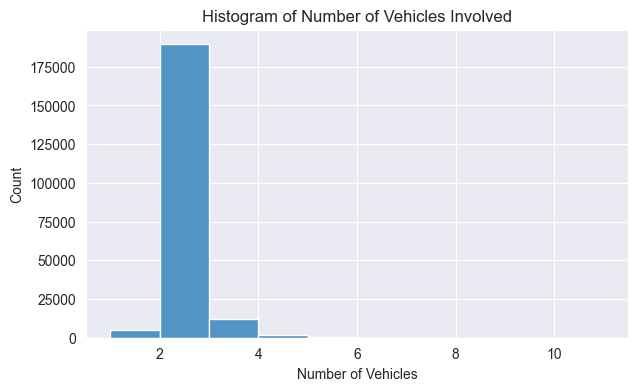

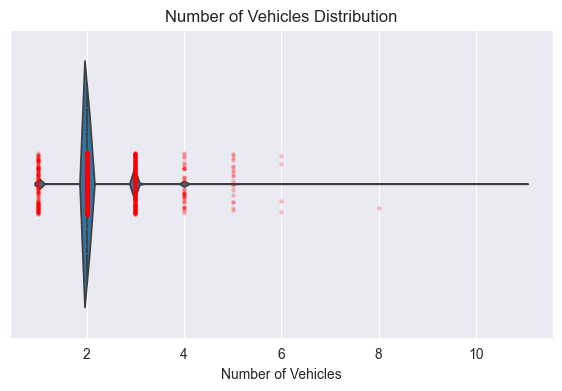

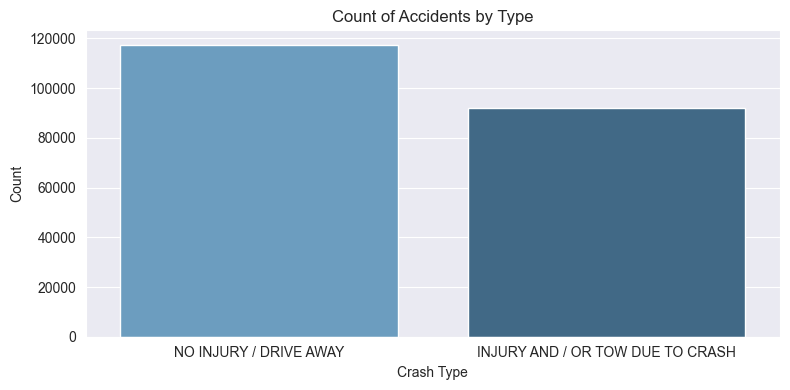

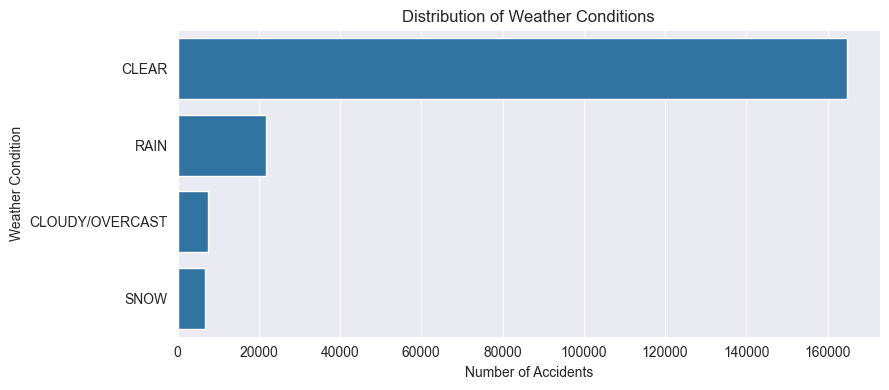

In [10]:
# 1. Histogram for numeric column
plt.figure(figsize=(7,4))
sns.histplot(df["num_units"], bins=10, color="#1f77b4")
plt.title("Histogram of Number of Vehicles Involved")
plt.xlabel("Number of Vehicles")
plt.ylabel("Count")
plt.xticks(rotation=0, ha="center")
plt.show()

# 2.stripplot for numeric column
plt.figure(figsize=(7,4))
plot_df = df.sample(5000, random_state=42)
sns.violinplot(x=df["num_units"], inner="quartile", color="#1f77b4")
sns.stripplot(x=plot_df["num_units"], jitter=True, size=3, alpha=0.25, color="red")
plt.title("Number of Vehicles Distribution")
plt.xlabel("Number of Vehicles")
plt.show()

# 3. Bar chart for categorical column

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="crash_type",
    hue="crash_type",
    order=df["crash_type"].value_counts().index,
    palette="Blues_d",
    legend=False
)

plt.title("Count of Accidents by Type")
plt.xlabel("Crash Type")
plt.ylabel("Count")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()

#4.Show the weather condition distribution

weather_df = df[
    ~df["weather_condition"].isin(["MISSING", "OTHER_RARE"])
].copy()

weather_counts = weather_df["weather_condition"].value_counts()

plt.figure(figsize=(9, 4))

sns.barplot(
    x=weather_counts.values,
    y=weather_counts.index
)

plt.title("Distribution of Weather Conditions")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")

plt.tight_layout()
plt.show()

- The majority of accidents involve 2 vehicles, with a small proportion involving 3–11 vehicles. Stripplot shows some extreme values flagged as outliers.
- Most accidents are "NO INJURY / DRIVE AWAY", followed by "INJURY AND/OR TOW DUE TO CRASH". Accident type distribution is uneven, which may affect later comparisons.
- Most accidents occur under clear weather conditions, while rain, cloudy/overcast, and snow are much less frequent.

### Section 3: Bivariate Analysis

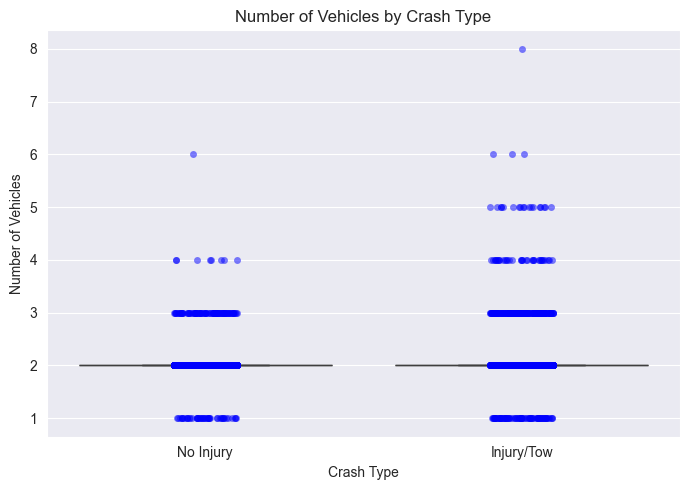

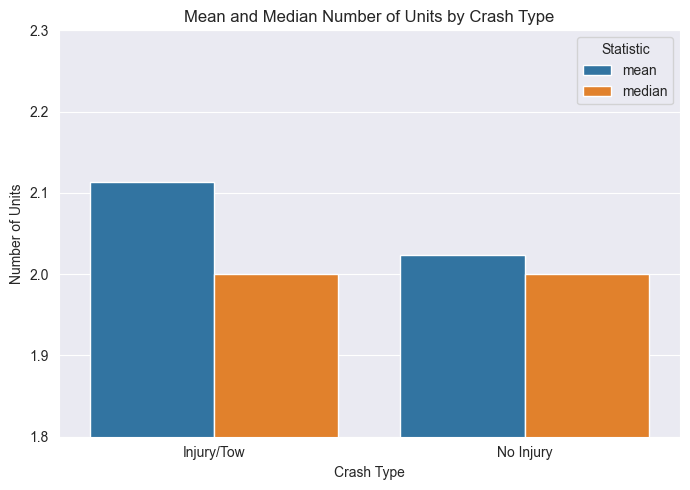

<Figure size 1000x500 with 0 Axes>

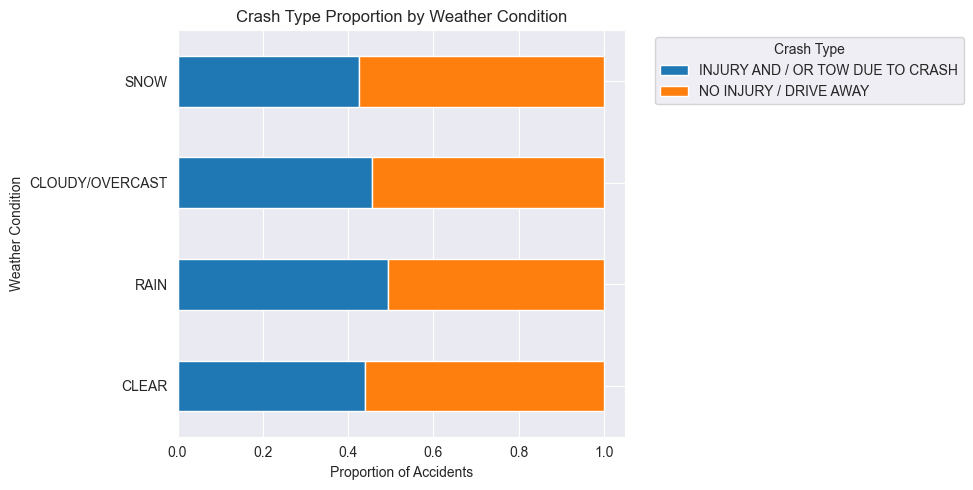

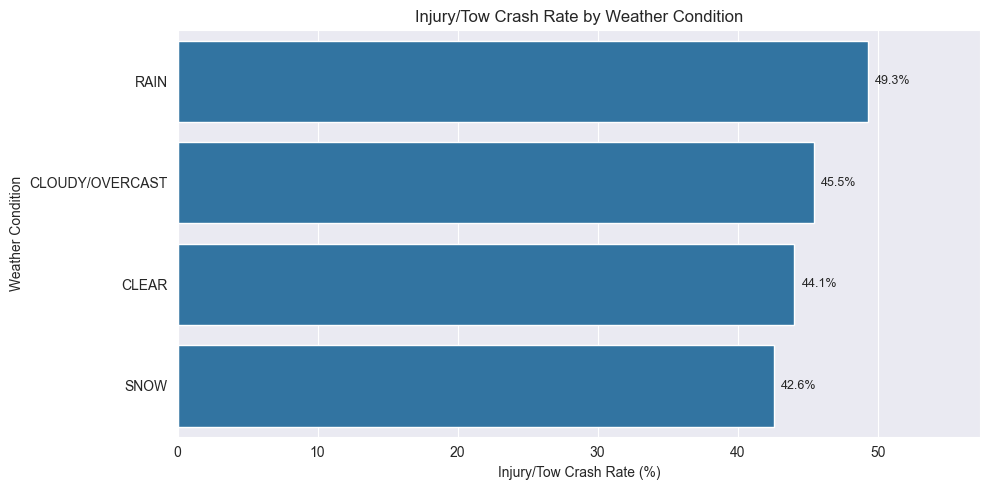

,weather_condition,injury_tow_rate_percent,count
0,RAIN,49.308819,21702
1,CLOUDY/OVERCAST,45.472650,7532
2,CLEAR,44.058224,164673
3,SNOW,42.568059,6869


In [11]:
# Create shorter labels for x-axis
df["crash_type_short"] = df["crash_type"].replace({
    "NO INJURY / DRIVE AWAY": "No Injury",
    "INJURY AND / OR TOW DUE TO CRASH": "Injury/Tow"
})

plot_df = df.sample(5000, random_state=42)

# Bivariate Analysis 1: Number of Units by Crash Type

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="crash_type_short",
    y="num_units",
    hue="crash_type_short",
    showfliers=False,
    legend=False
)

sns.stripplot(
    data=plot_df,
    x="crash_type_short",
    y="num_units",
    jitter=True,
    size=5,
    alpha=0.5,
    color="blue"
)

plt.title("Number of Vehicles by Crash Type")
plt.xlabel("Crash Type")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()


# Bivariate Analysis 2: Mean and Median Number of Units by Crash Type

summary_units = (
    df.groupby("crash_type_short")["num_units"]
    .agg(["mean", "median"])
    .reset_index()
)

summary_long = summary_units.melt(
    id_vars="crash_type_short",
    value_vars=["mean", "median"],
    var_name="Statistic",
    value_name="Number of Units"
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=summary_long,
    x="crash_type_short",
    y="Number of Units",
    hue="Statistic"
)

plt.title("Mean and Median Number of Units by Crash Type")
plt.xlabel("Crash Type")
plt.ylabel("Number of Units")
plt.xticks(rotation=0, ha="center")
plt.ylim(1.8, 2.3)
plt.tight_layout()
plt.show()

# Categorical vs Categorical: Cross-tab
cross_tab = pd.crosstab(df["crash_type"], df["weather_condition"], normalize="index")
cross_tab

# Weather and accident (stacked proportion)

weather_df = df[
    df["weather_condition"].notna() &
    ~df["weather_condition"].isin(["MISSING", "OTHER_RARE"])
].copy()

weather_order = weather_df["weather_condition"].value_counts().index

weather_crash_prop = pd.crosstab(
    weather_df["weather_condition"],
    weather_df["crash_type"],
    normalize="index"
).loc[weather_order]

plt.figure(figsize=(10, 5))

weather_crash_prop.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Crash Type Proportion by Weather Condition")
plt.xlabel("Proportion of Accidents")
plt.ylabel("Weather Condition")
plt.legend(title="Crash Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Weather condition and severity

weather_df = df[
    df["weather_condition"].notna() &
    ~df["weather_condition"].isin(["MISSING", "OTHER_RARE"])
].copy()

weather_df["is_injury_tow"] = (
    weather_df["crash_type"] == "INJURY AND / OR TOW DUE TO CRASH"
).astype(int)

weather_target = (
    weather_df.groupby("weather_condition")
      .agg(
          injury_tow_rate=("is_injury_tow", "mean"),
          count=("is_injury_tow", "size")
      )
      .reset_index()
)

weather_target["injury_tow_rate_percent"] = weather_target["injury_tow_rate"] * 100

weather_target = weather_target.sort_values(
    by="injury_tow_rate_percent",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=weather_target,
    x="injury_tow_rate_percent",
    y="weather_condition"
)

plt.title("Injury/Tow Crash Rate by Weather Condition")
plt.xlabel("Injury/Tow Crash Rate (%)")
plt.ylabel("Weather Condition")

for i, value in enumerate(weather_target["injury_tow_rate_percent"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.xlim(0, weather_target["injury_tow_rate_percent"].max() + 8)

plt.tight_layout()
plt.show()

weather_target[["weather_condition", "injury_tow_rate_percent", "count"]]

- Both crash types have a median of around 2 units, meaning the typical accident involves two vehicles. However, the mean number of units is slightly higher for `INJURY AND / OR TOW DUE TO CRASH`, suggesting that more severe crash types are more likely to involve additional vehicles.
- Weather conditions show different crash severity patterns, with rain having the highest Injury/Tow crash rate, while clear and snow conditions show relatively lower rates.

### Section 4: Multivariate Analysis

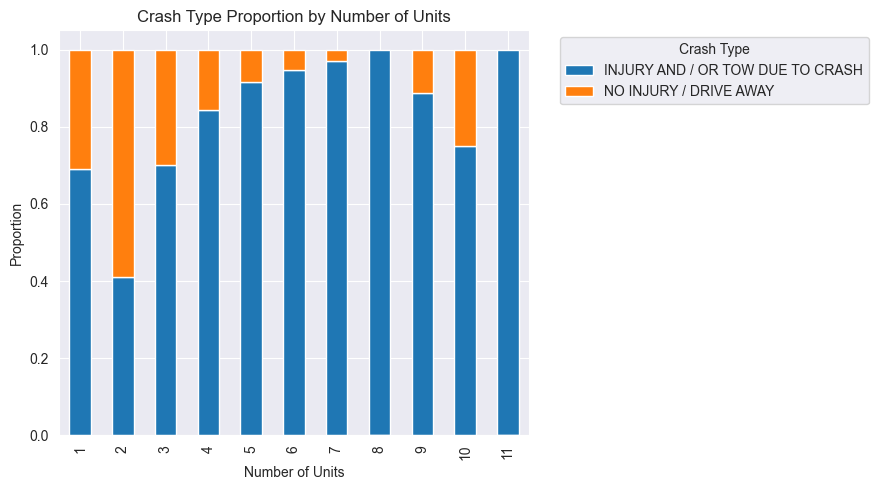

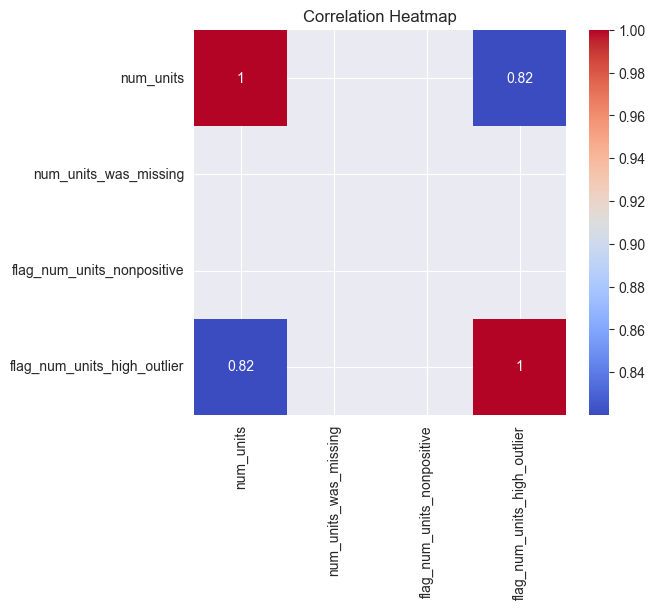

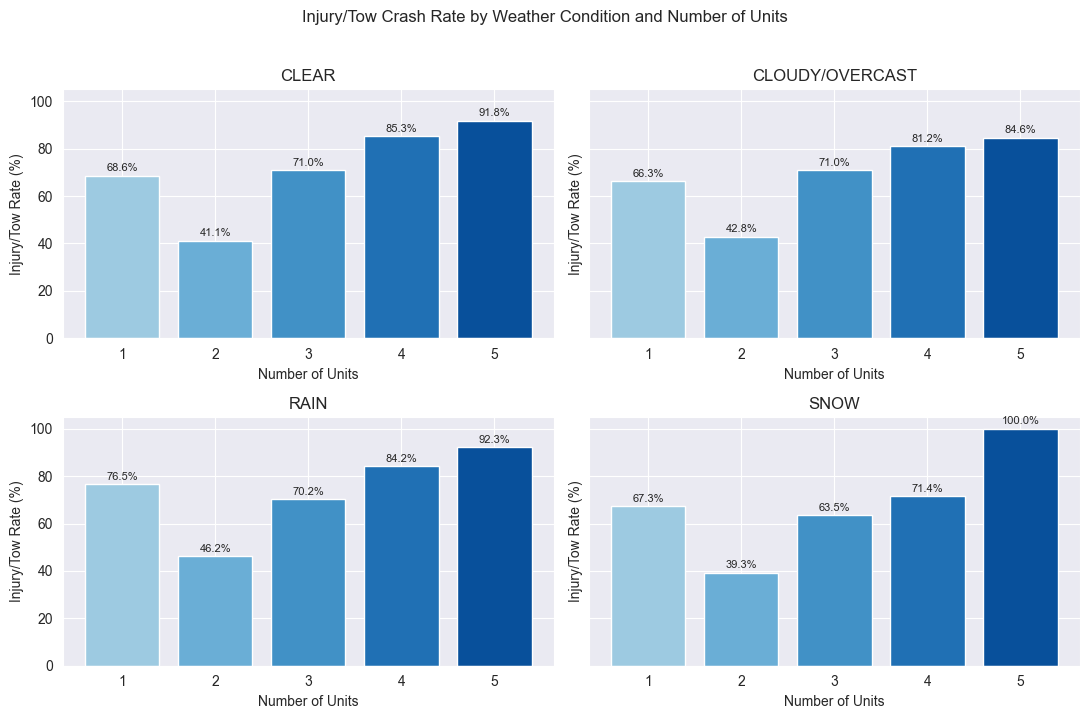

In [18]:
# Bar chart with hue for grouping
ct = pd.crosstab(
    df["num_units"],
    df["crash_type"],
    normalize="index"
)

ct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Crash Type Proportion by Number of Units")
plt.xlabel("Number of Units")
plt.ylabel("Proportion")
plt.legend(title="Crash Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric columns
numeric_cols = ["num_units", "num_units_was_missing", "flag_num_units_nonpositive", "flag_num_units_high_outlier"]
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


#Weather Condition × Number of Units × Crash Type
weather_df = df[
    df["weather_condition"].notna() &
    ~df["weather_condition"].isin(["MISSING", "OTHER_RARE"])
].copy()

weather_df["is_injury_tow"] = (
    weather_df["crash_type"] == "INJURY AND / OR TOW DUE TO CRASH"
).astype(int)

weather_target = (
    weather_df.groupby(["weather_condition", "num_units"])
    .agg(
        injury_tow_rate=("is_injury_tow", "mean"),
        count=("is_injury_tow", "size")
    )
    .reset_index()
)

weather_target["injury_tow_rate_percent"] = weather_target["injury_tow_rate"] * 100

weather_target = weather_target[weather_target["num_units"].between(1, 5)].copy()

weather_order = ["CLEAR", "CLOUDY/OVERCAST", "RAIN", "SNOW"]

num_units_order = [1, 2, 3, 4, 5]

colors = sns.color_palette("Blues", n_colors=len(num_units_order) + 2)[2:]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes = axes.flatten()

for ax, weather in zip(axes, weather_order):
    sub = weather_target[weather_target["weather_condition"] == weather].copy()

    sub = (
        sub.set_index("num_units")
        .reindex(num_units_order)
        .reset_index()
    )

    bars = ax.bar(
        sub["num_units"],
        sub["injury_tow_rate_percent"],
        color=colors
    )

    ax.set_title(weather)
    ax.set_xlabel("Number of Units")
    ax.set_ylabel("Injury/Tow Rate (%)")
    ax.set_xticks(num_units_order)
    ax.set_xticklabels([str(x) for x in num_units_order])
    ax.set_ylim(0, 105)

    for bar, value in zip(bars, sub["injury_tow_rate_percent"]):
        if pd.notna(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 1,
                f"{value:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8
            )

plt.suptitle("Injury/Tow Crash Rate by Weather Condition and Number of Units", y=1.02)

plt.tight_layout()
plt.show()

- The stacked bar chart shows how crash type proportions change as the number of units involved increases. Crashes with more units tend to have a larger share of `INJURY AND / OR TOW DUE TO CRASH`, suggesting that multi-unit crashes are more likely to result in injury or towing.
- Correlation heatmap shows strong positive correlation between num_units and flag_num_units_high_outlier, confirming that accidents with more vehicles tend to be considered extreme events.
- Injury/Tow rates generally increase as the number of units involved rises across different weather conditions.

### Section 5: Hypothesis-driven EDA Example

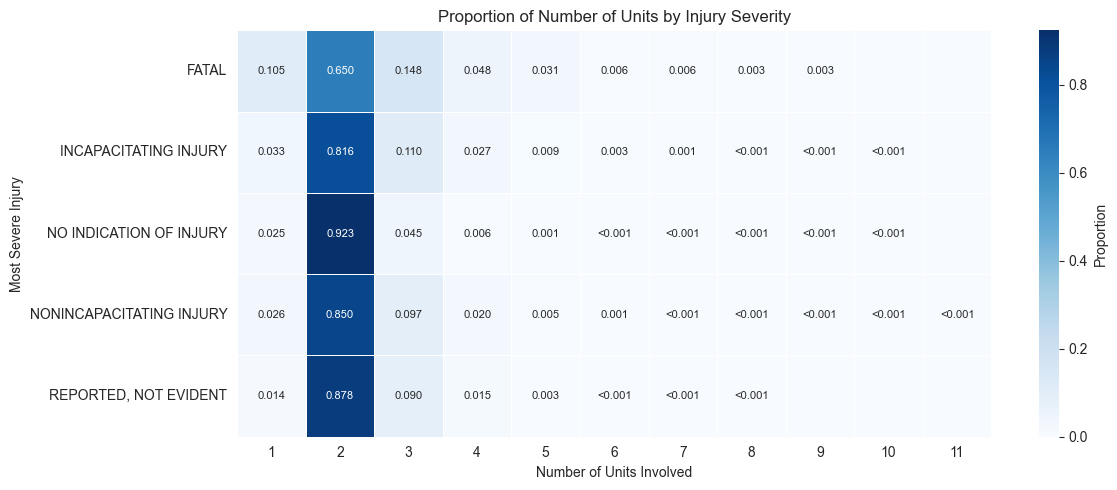

num_units
1       5123
2     189337
3      12249
4       1908
5        453
6        135
7         34
8         22
9          9
10         4
11         1
Name: count, dtype: int64


In [7]:
# Hypothesis: Multi-unit accidents may be associated with higher injury severity

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a row-normalized cross-tabulation
ct = pd.crosstab(
    df["most_severe_injury"],
    df["num_units"],
    normalize="index"
)

# Create annotation labels
annot_labels = ct.copy().astype(str)

for row in ct.index:
    for col in ct.columns:
        value = ct.loc[row, col]
        if value == 0:
            annot_labels.loc[row, col] = ""
        elif value < 0.001:
            annot_labels.loc[row, col] = "<0.001"
        else:
            annot_labels.loc[row, col] = f"{value:.3f}"

# Plot heatmap
plt.figure(figsize=(12, 5))

sns.heatmap(
    ct,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "Proportion"}
)

plt.title("Proportion of Number of Units by Injury Severity")
plt.xlabel("Number of Units Involved")
plt.ylabel("Most Severe Injury")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Numeric summary: number of crashes by number of units
unit_counts = df["num_units"].value_counts().sort_index()
print(unit_counts)

Hypothesis: Accidents involving more vehicles tend to be more severe.

- The heatmap shows that two-unit crashes dominate every injury severity category. For example, around 92% of crashes with no indication of injury involve two units, and two-unit crashes are also the largest group for fatal crashes.

- However, the distribution is not identical across severity levels. Fatal crashes have a higher proportion of one-unit crashes and three-unit crashes compared with no-injury crashes. This suggests that `num_units` is related to injury severity, but the relationship is not simply “more units means more severe.” Most crashes still involve two units, so `num_units` should be used together with other features such as crash type, weather, lighting, and roadway conditions.